In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator
import os
import numpy as np
from copy import deepcopy
import pandas as pd


In [3]:
import NNMFit
from NNMFit.utilities.readout_graphs import HistogramGraph
from NNMFit.core.analysis_config import AnalysisConfig

In [4]:
x_labels = {
    "reco_energy" : r"Reco $E_{\rm dep}$ [GeV]",
    "reco_length" : r"Reco $L_{\tau}$ [m]",
    "reco_zenith" : r"Reco $\theta$ [rad]",
    "reco_azimuth" : r"Reco azimuth [rad]",
    "reco_dir" : r"Reco $\theta$ [rad]",
    "bdt_product" : "BDT score 1 x BDT score 2",
    "bdt_scores1" : "BDT score 1",
    "bdt_scores2" : "BDT score 2",
}

def plot_histogram(config_hdl, hist_graph_hdl, det_config, input_variables, ylog=None, title=None, savepath=None, mc_key="All"):

    print(det_config)
    binnings = hist_graph_hdl.get_binning(det_config=det_config)
    data_path = config_hdl.to_dict()["config"][det_config]["data"]

    if data_path.endswith(".parquet"):
        data_df = pd.read_parquet(data_path)
    else:
        data_df = pd.read_hdf(data_path)

    fig, axes = plt.subplots(2, len(binnings), figsize=(len(binnings)*5, 6),
                              gridspec_kw={"height_ratios": [3, 1]},
                              sharex="col", squeeze=False)

    print(data_path)

    # Bin data once per variable
    data_hists = {}
    for variable_name, binning in binnings.items():
        if variable_name == "reco_zenith":
            data_hists["reco_zenith"], _ = np.histogram(data_df["reco_dir"], bins=binning)
        else:
            data_hists[variable_name], _ = np.histogram(data_df[variable_name], bins=binning)
        print("data", variable_name, sum(data_hists[variable_name]))

    mc_hists = {}

    for input_name, input_variable in input_variables.items():
        res = hist_graph_hdl.get_evaled_histogram(input_variables=input_variable, det_config=det_config, reshape=True)

        for i, (variable_name, binning) in enumerate(binnings.items()):
            sum_axes = tuple(ax for ax in range(res["mu"].ndim) if ax != i)

            hist = res["mu"].sum(axis=sum_axes)
            yerror = np.sqrt(res["ssq"].sum(axis=sum_axes))

            ax = axes[0, i]
            ax.stairs(hist, binning, label=f"{input_name}: {sum(hist):.2f}+-{sum(yerror):.2f}")
            ax.fill_between(binning, np.r_[hist - yerror, (hist - yerror)[-1]], np.r_[hist + yerror, (hist + yerror)[-1]], step="post", alpha=0.4)

            ax.set_ylabel(f"Rate / {hist_graph_hdl.get_livetime(det_config)/(3600*24*365.25):.2f} yr")
            ax.set_xlim(min(binning), max(binning))
            ax.set_yscale("log") if ylog else 0
            if "energy" in variable_name or "length" in variable_name:
                ax.set_xscale("log")

            if input_name == mc_key:
                mc_hists[variable_name] = hist

    # Overlay data and draw ratio panel
    for i, (variable_name, binning) in enumerate(binnings.items()):
        bin_centers = 0.5 * (binning[:-1] + binning[1:])
        data_hist = data_hists[variable_name]
        data_err = np.sqrt(data_hist)

        ax_main = axes[0, i]
        ax_main.errorbar(bin_centers, data_hist, yerr=data_err, fmt="k.", capsize=2,
                         label=f"Data: {int(sum(data_hist))}")
        # if not i:
            # ax_main.legend()
        ax_main.legend()

        ax_ratio = axes[1, i]
        if variable_name in mc_hists:
            mc_hist = mc_hists[variable_name]
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = np.where(mc_hist > 0, data_hist / mc_hist, np.nan)
                ratio_err = np.where(mc_hist > 0, data_err / mc_hist, np.nan)
            ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt="k.", capsize=2)
            ax_ratio.axhline(1, color="gray", linestyle="--", linewidth=0.8)
        ax_ratio.set_ylabel("Data / MC")
        ax_ratio.set_xlabel(x_labels[variable_name])
        ax_ratio.set_xlim(min(binning), max(binning))
        if "energy" in variable_name or "length" in variable_name:
            ax_ratio.set_xscale("log")

    plt.suptitle(det_config) if not title else plt.suptitle(title)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    plt.show()

In [5]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step1_hese_flux/data_mc"
os.system(f"mkdir -p {plotting_path}")

0

In [6]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"

config_hdl = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/hese/hese_spectrum_bestfit_13year_round3.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=[ 
                                "override/systematics/Snowstorm_Gradients_hese_HESEBestfit_SPL_wpriors.cfg",
                                "override/binning/hese/10bdtprod_threshold_0.122.cfg",
                                "override/livetime/hese_livetime_13yr.cfg",
                                "override/datasets_GP_globalfit/v3/globalfit_hese_clean_globalfit_v3.cfg"],
        override_components_files=["override/components/astro_SPL_no_inel_no_flavor.yaml",
                                   "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
        override_parameters_files=None)
hist_graph_hdl = HistogramGraph(config_hdl)
detector_configs = config_hdl.get_det_configs()



IC86_pass2_SnowStorm_FTP_HESE_Cascades
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split/data_HESE_pass2/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10/dataset_data_HESE_pass2_cascade.parquet
data reco_energy 70
data reco_zenith 122


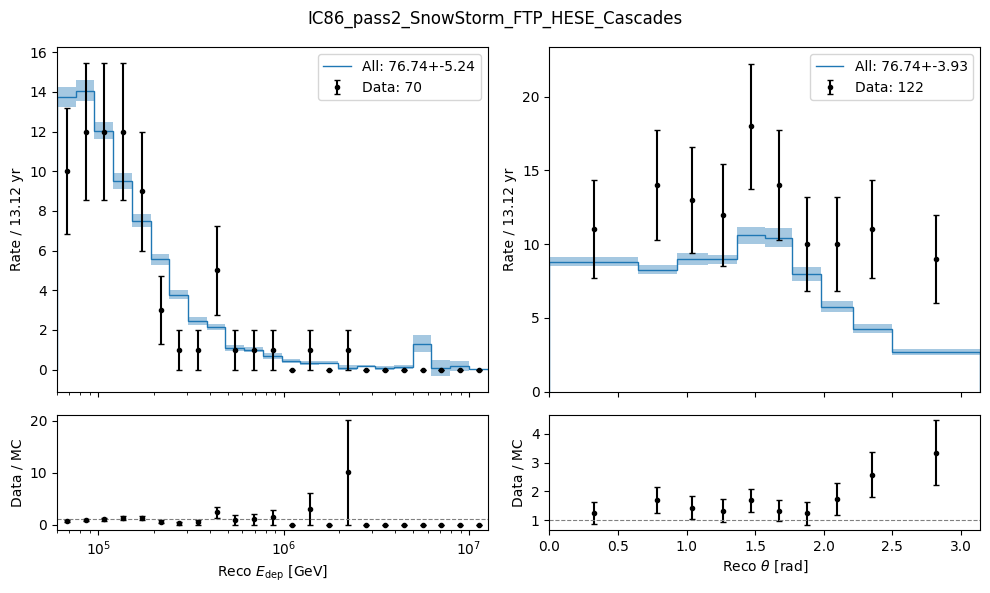

IC86_pass2_SnowStorm_FTP_HESE_Tracks
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split/data_HESE_pass2/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10/dataset_data_HESE_pass2_track.parquet
data reco_energy 44
data reco_zenith 69


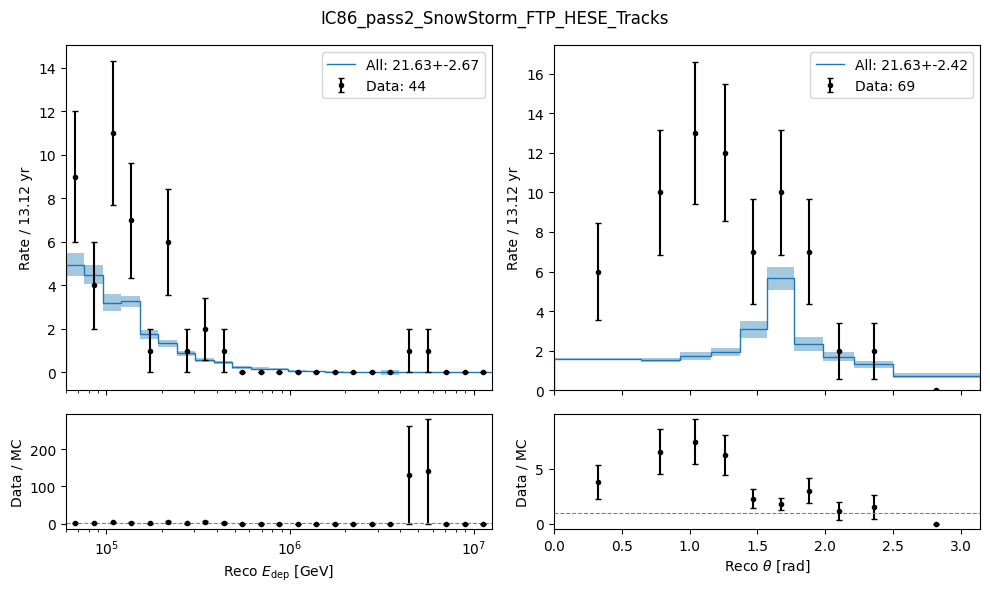

In [7]:
input_variables = {
    r"All" : {},
    # r"Conventional $\nu$" : {"astro_norm" : 0, "conv_norm" : 1.0638217360248496, "muongun_norm" : 0},
    # r"Atmospheric $\mu$" : {"astro_norm" : 0, "conv_norm" : 0, "muongun_norm" : 1.4572392109257732},
    # r"Astro" : {"astro_norm" : 2.2442548547245496, "conv_norm" : 0, "muongun_norm" : 0},
    # r"Nothing" : {"astro_norm" : 0.0, "conv_norm" : 0, "muongun_norm" : 0, "prompt_norm" : 0, "muon_norm" : 0, "total_astro_norm" : 0},
}

for det_config in ["IC86_pass2_SnowStorm_FTP_HESE_Cascades","IC86_pass2_SnowStorm_FTP_HESE_Tracks"]: 
    plot_histogram(config_hdl=config_hdl,hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=False, 
                savepath=f"{plotting_path}/{det_config}_ylog-False.png")
    # break